# Colab으로 진행

In [1]:
# !brew tap homebrew/cask-fonts
# !brew install --cask font-nanum
# !fc-cache -fv
# !rm -rf ~/Library/Caches/matplotlib


In [2]:
%%capture
# capture는 주렁주렁 출력 보여주지 않게끔
# Font 설치

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

위의 코드 실행 후에 세션을 다시 시작

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# numpy 및 matplotlib 작동 확인
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

# 간단한 그래프 출력 테스트
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Test Plot")
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# !pip install gdown
# !pip install einops
# !pip install transformers
# !pip install sentencepiece
# !pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 46.6 MB/s eta 0:00:00


In [ ]:
# import torch

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # 새롭게 처음부터 훈련을 하고 싶으면 True로 설정 하면 됩니다. 대략 1시간 정도 걸려요(A100 gpu 기준)
# train_model = False

# DEVICE

'cuda'

In [34]:
# 파이토치를 이용해 모델 객체를 만들고 나서 어떤 장치(device) 환경에서 훈련이나 추론을 수행할지 결정지어주기

import torch

# MPS 지원 여부 확인
if torch.backends.mps.is_available():
    device = 'mps'  # Apple Silicon에서 MPS 사용
elif torch.cuda.is_available():
    device = 'cuda'  # CUDA 사용 가능 시
else:
    device = 'cpu'  # 그 외에는 CPU 사용

DEVICE = device

print(f"Using device: {DEVICE}")

Using device: mps


# 모델 구현

## MHA (Multi Head Attention)
Encoder, Decoder의 Self Attention을 수행하는 모듈

### einops 사용하기
- 장점 : 텐서의 변환을 매우 쉽게 이해하고 변환 시킬 수 있다.
- 단점 : 오류 잡기가 매우 힘들다. 속도도 조금 느리다.

In [8]:
from einops import rearrange

# 차원 재배치
x = torch.randn(2, 3, 4) # Tensor Shape : (2, 3, 4)
y = rearrange(x, 'a b c -> c a b') # Tensor Shape

y.shape

torch.Size([4, 2, 3])

In [9]:
# 차원 합치기

x = torch.randn(2, 3, 4)
y = rearrange(x, 'a b c -> (a b) c')

y.shape

torch.Size([6, 4])

In [10]:
# 차원 나누기

x = torch.randn(6, 4)
y = rearrange(x, '(a b) c -> a b c', a=2)

y.shape

torch.Size([2, 3, 4])

## MHA 구현

In [11]:
from torch import nn
from einops import rearrange
import torch

# MHA : Multi Head Attention

class MHA(nn.Module):



    def __init__(self, d_model=512, n_heads=8):

        '''
        d_model : 임베딩 벡터의 차원 (dimension of embedding vector). 논문에서 512개로 구현
        n_heads : 멀티 헤드 어텐션의 헤드 개수 (number of heads in multi-head attention) 논문에서 8개로 구현됨
        '''

        super().__init__()

        self.n_heads = n_heads

        # Query, Key, Value 벡터를 위한 선형 레이어를 정의
        self.fc_q = nn.Linear(d_model, d_model)
        self.fc_k = nn.Linear(d_model, d_model)
        self.fc_v = nn.Linear(d_model, d_model)

        # 최종 출력을 위한 선형 레이어
        self.fc_o = nn.Linear(d_model, d_model)

        # 어텐션 스코어를 스케일링 하기 위한 값. (d_model / n_heads의 제곱근)
        self.scale = torch.sqrt(torch.tensor(d_model / n_heads)) # 512 / 8의 root 씌운거. 8



    def forward(self, Q, K, V, mask=None):

        """
        Q, K, V : 단어가 임베딩 레이어를 통과한 결과입니다. 즉 임베딩 벡터!

        Shape은 (N, t, D) : (batch_size, max_len, dimension)

        mask : 어텐션 스코어에 적용할 마스크 (optional)
        """

        # 임베딩 벡터인 Q, K, V에 대한 선형 변환 적용
        Q = self.fc_q(Q) # -> (N, t, D) -> (N, t, D)
        K = self.fc_k(K) # -> (N, t, D) -> (N, t, D)
        V = self.fc_v(V) # -> (N, t, D) -> (N, t, D)

        # Multi Head를 위해 임베딩 차원 D를 Head 갯수 n_heads로 분할하기
        # 예를 들어 (32, 128, 512)로 들어왔을 때, 8개의 Head로 나누게 되면 (32, 8, 128, 64)
        Q = rearrange(Q, 'N t (h dk) -> N h t dk', h=self.n_heads) # (N, t, D) -> (N, h, t, D//h) : (32, 128, 512) -> (32, 8, 128, 64)
        K = rearrange(K, 'N t (h dk) -> N h t dk', h=self.n_heads) # (N, t, D) -> (N, h, t, D//h) : (32, 128, 512) -> (32, 8, 128, 64)
        V = rearrange(V, 'N t (h dk) -> N h t dk', h=self.n_heads) # (N, t, D) -> (N, h, t, D//h) : (32, 128, 512) -> (32, 8, 128, 64)

        # 어텐션 스코어 구하기 (소프트맥스 통과 전) QK^T / 루트d_k
        #  Q와 K^T의 내적을 통해 어텐션 스코어를 계산하고, 스케일링 적용

        # (N, h, t, dk) @ (N, h, dk, t) ------(dk, dk 없어지고 t, t만 남게 되므로)----> (N, h, t(Query의 길이), t(Key의 길이))
        attention_score = Q @ K.transpose(-2, -1) / self.scale

        # 패딩의 위치에다가 굉장히 작은 값을 강제로 부여 -> 소프트맥스 적용 시에 0이 될 수 있도록
        if mask is not None: # 패딩 위치를 의미하는 인덱스들이 존재한다면
            attention_score[mask] = -1e10 # 마스크에 해당하는 위치에 굉장히 작은 값을 넣어준다.

        # 에너지 값을 구하기 위해서는 키의 방향으로 SoftMax를 적용한다.
        energy = torch.softmax(attention_score, dim=-1)

        # 에너지와 Value를 곱해서 최종 Attention 값을 구한다
        attention = energy @ V # (N, h, t(Query의 길이), t(Key의 길이)) @ (N, h, t(Key의 길이), dk) -> (N, h, t(Query의 길이), dk)

        # Head 차원을 연결해서 원래의 차원으로 되돌리기
        x = rearrange(attention, 'N h t dk -> N t (h dk)')  # (N, h, t, dk) -> (N, t, D)

        # 최종 출력값에 대해 선형 변환을 적용한다. 각각의 Head의 생각을 섞어준다.
        x = self.fc_o(x) # (N, t, D) -> (N, t, D)

        return x, energy

## FNN(Feed Forward Network)
정확한 이름은 Position-wise Feed Forward network라고 한다. 인코더, 디코더의 Multi Head Attention의 결과를 하나로 합쳐주는 역할을 수행한다.

In [12]:
class FeedForward(nn.Module):

    def __init__(self, d_model=512, d_ff=2048, drop_p=0.1):
        super().__init__()

        self.linear = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, mha_output):
        out = self.linear(mha_output)
        return out

## Encoder 구현

In [13]:
# MHA - FFN 연결 과정 구현
#  추가적으로 skip connection, LN 까지 구현
class EncoderLayer(nn.Module):

    def __init__(self, d_model, d_ff, n_heads, drop_p):
        """
        d_model : 임베딩 벡터의 차원
        d_ff : 피드 포워드 신경망의 은닉층의 차원
        n_heads : 멀티 헤드 어텐션의 헤드 개수
        drop_p : 드롭아웃 비율
        """
        super().__init__()

        # Multi Head Attention 레이어 정의 (Self-Attention)
        self.self_atten = MHA(d_model, n_heads)

        # MHA에 대한 Layer Normalization 정의
        self.self_atten_LN = nn.LayerNorm(d_model)

        # 피드 포워드 네트워크 정의
        self.FF = FeedForward(d_model, d_ff, drop_p)

        # 피드 포워드 네트워크의 출력에 대한 Layer Normalization
        self.FF_LN = nn.LayerNorm(d_model)

        # 드롭아웃 레이어 정의
        self.dropout = nn.Dropout(drop_p)


    def forward(self, x, enc_mask):
        """
            x : 입력 텐서, Shape은 (batch_size, seq_len, d_model) -> Projection Layer
            enc_mask : 입력 마스크, Shape은 (batch_size, 1, seq_len)

             return : 인코더 레이어의 출력과 어텐션 가중치(에너지)
        """

        # Multi Head Attention 블록 구현
        #  리니어 레이어를 지나기 전에는 Q=K=V 이다. 이거를 x로 받아오고 있음

        residual, atten_enc = self.self_atten(Q=x, K=x, V=x, mask=enc_mask)
        residual = self.dropout(residual)

        # Skip Connection(Add) & Layer Norm
        encoder_self_attention_output = self.self_atten_LN(x + residual)

        # FFN 블록
        residual = self.FF(encoder_self_attention_output)
        residual = self.dropout(residual)

        # Skip Connection & Layer Norm
        encoder_ffn_output = self.FF_LN(encoder_self_attention_output + residual)

        return encoder_ffn_output, atten_enc

In [14]:
class Encoder(nn.Module):

    def __init__(self, input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p):
        """
            input_embedding : 입력 임베딩 레이어 (nn.Embedding)
            max_len : 입력 시퀀스의 최대 길이 (int)
            n_layers : 인코더 레이어의 개수
            d_model : 임베딩 벡터의 차원
            d_ff : 피드 포워드 신경망의 은닉층의 차원
            n_heads : 멀티 헤드 어텐션의 헤드 개수
            drop_p : 드롭아웃 비율
        """
        super().__init__()

        # d_model의 제곱근 값으로 scale을 정의하여 임베딩 벡터의 크기를 조정
        self.scale = torch.sqrt(torch.tensor(d_model))

        # 입력 임베딩 레이어
        self.input_embedding = input_embedding

        # 위치 임베딩 레이어 : 입력 시퀀스의 위치 정보를 학습하기 위한 레이어. 최근에는 위치 정보도 학습의 대상으로 보기 위함
        self.pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(drop_p)

        # 여러 개의 인코더 레이어를 쌓기 위해 모듈 리스트를 활용
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, d_ff, n_heads, drop_p) for _ in range(n_layers)]
        )

        self.device = DEVICE

    def forward(self, src, mask, atten_map_save=False):
        '''
        src : 입력 시퀀스 (batch_size, seq_len)
        mask : 패딩을 마스킹하기 위한 마스크 텐서 (batch_size, 1, seq_len)
        atten_map_save : 어텐션 맵을 저장할지 여부 (기본값: False)
        '''

        # 위치 인덱스 텐서 생성 : 각 배치에서 시퀀스의 길이만큼 위치 인덱스를 반복
        pos = torch.arange(src.shape[1]).repeat(src.shape[0], 1).to(self.device) # -> 배치 사이즈만큼 반복하는데, 단어의 배치 사이즈만큼 1번 방향으로 늘리기

        # 입력 임베딩과 위치 임베딩을 합산해서 입력 텐서 x 생성
        x_embedding = self.scale * self.input_embedding(src) + self.pos_embedding(pos)

        # Dropout
        x_embedding = self.dropout(x_embedding)

        # 제일 처음 입력
        encoder_output = x_embedding

        # 인코더의 에너지 값들을 저장할 비어있는 텐서
        atten_encs = torch.tensor([]).to(self.device)

        # 각 인코더 레이어를 순차적으로 통과
        for layer in self.layers:

            # 인코더 레이어를 통과시키면 encoder_output과 에너지 값을 얻는다
            encoder_output, atten_enc = layer(encoder_output, mask)

            # atten_map_save가 True이면 에너지 저장
            if atten_map_save:

                # 현재 어탠션 맵을 기존의 atten_encs에 추가 (첫 번째 레이어의 어텐션 맵만 저장)
                atten_encs = torch.cat([atten_enc, atten_enc[0].unsqueeze(0)])

        return encoder_output, atten_encs

## Decoder

Masking 실험

In [15]:
import torch

# 예제 설정
batch_size = 3
seq_len = 10 # 단어의 갯수
padding = 3
n_heads = 8

# attention_score 텐서 생성 (무작위 값으로 초기화)
# Shape: (batch_size, n_heads, seq_len, seq_len)
attention_score = torch.randn(batch_size, n_heads, seq_len, seq_len)

# enc_mask 생성: 패딩이 있는 위치를 마스킹
# 각 시퀀스의 마지막 3개 위치에 패딩이 있다고 가정합니다.
enc_mask = torch.tensor([
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # 첫 번째 시퀀스
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # 두 번째 시퀀스
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]   # 세 번째 시퀀스
], dtype=torch.bool).unsqueeze(1).unsqueeze(2)  # Shape: (batch_size, 1, 1, seq_len)

# enc_mask의 shape을 (batch_size, n_heads, seq_len, seq_len)로 확장
enc_mask = enc_mask.expand(batch_size, n_heads, seq_len, seq_len)

print("="*20, "attention_score에 마스킹 적용 전", "="*20)
print("attention_score[0, 0] (첫 번째 배치, 첫 번째 헤드):\n",attention_score[0, 0])

# attention_score에 enc_mask 적용
if enc_mask is not None:
    attention_score[enc_mask] = 0  # 마스크된 위치에 매우 작은 값을 넣어 softmax 결과에 영향을 미치지 않도록 합니다.

print("="*20, "attention_score에 마스킹 적용 전", "="*20)
print("attention_score shape:", attention_score.shape)
print(enc_mask.shape)

# 이제 attention_score 텐서에서 마스크가 적용된 부분을 확인할 수 있습니다.
# 특정 헤드에 대한 attention_score 확인 (예: 첫 번째 헤드)
print("="*20, "attention_score에 마스킹 적용 후", "="*20)
print("attention_score[0, 0] (첫 번째 배치, 첫 번째 헤드):\n", attention_score[0, 0])

==================== attention_score에 마스킹 적용 전 ====================
attention_score[0, 0] (첫 번째 배치, 첫 번째 헤드):
 tensor([[-0.3045, -1.2690,  1.2731, -1.2984,  0.2721,  2.7174, -0.3116,  0.4199,
         -1.6879, -0.1197],
        [-0.0252, -0.7765,  0.9949,  2.1590,  0.1956,  0.3928,  0.5107,  0.4072,
          0.4645, -0.9903],
        [ 0.2987, -2.0506,  0.5943, -1.7323,  0.8831, -0.9537,  0.6305,  0.4176,
         -1.7962, -1.9480],
        [ 1.3569, -1.0415, -0.0094,  0.7731,  1.7437,  0.7871, -0.6887, -0.3878,
          1.4491,  2.1767],
        [ 2.9075, -0.4431,  0.2731,  0.8860, -0.5851, -0.1683, -0.6075,  0.4795,
         -0.3642, -1.8074],
        [-0.1374, -1.1370,  0.7717,  0.1519,  0.7904,  0.7806, -0.9638,  0.8861,
         -0.2299,  0.1766],
        [-0.6774,  1.1157,  0.2157,  1.1390,  0.0910, -0.2381,  0.6105,  0.4023,
          0.7385, -0.9946],
        [ 0.8001,  0.0713, -0.0521, -0.6022,  1.1739, -1.7063,  0.4884, -0.6619,
         -0.8244, -0.1828],
        [ 0.2565,

In [16]:
class DecoderLayer(nn.Module):



    def __init__(self, d_model, d_ff, n_heads, drop_p):

        super().__init__()

        # Decoder의 Self-Attention Layer -> Masked Multi Head Attention 정의.
        self.self_atten = MHA(d_model, n_heads) # forward할 때 Decoder Mask가 따로 부여
        self.self_atten_LN = nn.LayerNorm(d_model)

        # Encoder - Decoder Attention Layer
        self.enc_dec_atten = MHA(d_model, n_heads)
        self.enc_dec_atten_LN = nn.LayerNorm(d_model)

        # Feed Forward
        self.FF = FeedForward(d_model, d_ff, drop_p)
        self.FF_LN = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(drop_p)



    def forward(self, x, enc_out, dec_mask, enc_dec_mask):

        """
        x : 디코더의 입력 텐서 (batch_size, seq_len, d_model)
        enc_out : 인코더의 출력 텐서 (batch_size, seq_len, d_model)
        dec_mask : 디코더의 Self-Attention에 사용되는 마스크 (batch_size, 1, seq_len)
        enc_dec_mask : 인코더-디코더 Attention에 사용되는 마스크 (batch_size, 1, seq_len)

        return : 디코더 레이어의 출력 텐서, 디코더 Self-Attention 맵, 인코더-디코더 Attention 맵
        """

        # 1. Decoder의 Self-Attention
        residual, atten_dec = self.self_atten(Q=x, K=x, V=x, mask=dec_mask)
        residual = self.dropout(residual)
        decoder_masked_self_attention_output = self.self_atten_LN( x + residual)

        # 2. Encoder = Decoder Attention
            # Q는 Masked Multi Head Attention | K, V는 인코더의 출력
        residual, atten_dec_enc = self.enc_dec_atten(Q=decoder_masked_self_attention_output, K=enc_out, V=enc_out, mask=enc_dec_mask)

        residual = self.dropout(residual)
        decoder_self_attention_output = self.enc_dec_atten_Ln(x + residual)

        # 3. Feed Forward
        residual = self.FF(decoder_self_attention_output)
        residual = self.dropout(residual)
        decoder_output = self.FF_LN(decoder_self_attention_output + residual)

        # decoder_output : 디코더 출력값. 디코더가 N회 반복된 후 소프트맥스를 만나 단어를 출력하기 위한 값
        # atten_dec : Masked Self Attention의 에너지 맵
        # atten_dec_enc : Encoder에서 출력한 단어와, Decoder에서 출력할 단어의 에너지 맵
        return decoder_output, atten_dec, atten_dec_enc

In [17]:
class Decoder(nn.Module):



    def __init__(self, input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p, vocab_size):

        """
        vocab_size : Generator를 만들기 위해 필요함.
        """

        super().__init__()

        self.scale = torch.sqrt(torch.tensor(d_model))

        # 입력 Embedding Layer
        self.input_embedding = input_embedding

        # 위치 Embedding Layer
        self.pos_embedding = nn.Embedding(max_len, d_model)

        # Dropout
        self.dropout = nn.Dropout(drop_p)

        # 여러 개의 Dacoder Layer를 쌓기 위해 모듈 리스트 사용
        self.layers = nn.ModuleList(
            [ DecoderLayer(d_model, d_ff, n_heads, drop_p) for _ in range(n_layers) ]
        )

        # Generator 구현
        #   Decoder의 출력 벡터를 단어의 확률 분포로 변환
        #   Decoder의 출력 벡터는 Decoder Layer 연산을 N회 반복한 이후 나온다
        self.fc_out = nn.Linear(d_model, vocab_size)

        self.device = DEVICE



    def forward(self, trg, enc_out, dec_mask, enc_dec_mask, atten_map_save=False):
        """
            trg : 디코더의 입력 시퀀스 (target), Shape: (batch_size, seq_len)
            enc_out : 인코더의 출력 텐서, Shape: (batch_size, seq_len, d_model)
            dec_mask : 디코더의 Self-Attention에 사용되는 마스크 텐서, Shape: (batch_size, 1, seq_len)
            enc_dec_mask : 인코더-디코더 Attention에 사용되는 마스크 텐서, Shape: (batch_size, 1, seq_len)
            atten_map_save : 어텐션 맵을 저장할지 여부 (기본값: False)

            return : 디코더의 출력 텐서, 디코더 Self-Attention 맵, 인코더-디코더 Attention 맵
        """
        # 위치 인덱스 텐서 생성: 각 배치에서 시퀀스 길이만큼 위치 인덱스를 반복
        pos = torch.arange(trg.shape[1]).repeat(trg.shape[0], 1).to(self.device)  # (batch_size, seq_len)

        # 입력 임베딩과 위치 임베딩을 합산하여 입력 텐서 x를 생성
        # 입력 임베딩에 scale을 곱해 크기를 조정
        y_embedding = self.scale * self.input_embedding(trg) + self.pos_embedding(pos)  # (batch_size, seq_len, d_model)

        # 드롭아웃 적용
        y_embedding = self.dropout(y_embedding)

        # 어텐션 맵을 저장할 텐서 초기화 (빈 텐서로 시작)
        atten_decs = torch.tensor([]).to(self.device)
        atten_enc_decs = torch.tensor([]).to(self.device)

        # 제일 처음 입력은 y_embedding
        decoder_output = y_embedding

        # 각 Decoder Layer를 순차적으로 통과
        for layer in self.layers:
            decoder_out, atten_dec, atten_enc_dec = layer(decoder_output, enc_out, dec_mask, enc_dec_mask)

            if atten_map_save:
                atten_decs = torch.cat([atten_decs, atten_dec[0].unsqueeze()])
                atten_enc_decs = torch.cat([atten_enc_decs, atten_enc_dec[0].unsqueeze])


        # 최종 출력층(제너레이터)
        decoder_output_linear = self.fc_out(decoder_output)

        return decoder_output_linear, atten_decs, atten_enc_decs



## Transformer 구현
- 인코더, 디코더 조립
- 인코더, 디코더에 들어갈 마스크 생성

In [18]:
# 논문에서는 Input Embedding과 Output Embedding이 나뉘지만,
# Input Embedding으로 똑같이 넣나 Encoder와 Decoder 각각 나눠서 넣나 효과는 비슷하기에
# 우리는 나누지 않고 Input Embedding으로 똑같이 넣을 것

class Transformer(nn.Module):



    def __init__(self, vocab_size, max_len, n_layers, pad_idx, d_model=512, d_ff=2048, n_heads=8, drop_p=0.1):
        super().__init__()

        # Input Embedding Layer 정의
        self.input_embedding = nn.Embedding(vocab_size, d_model)

        # Encoder, Decoder
        self.encoder = Encoder(self.input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p)
        self.decoder = Decoder(self.input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p, vocab_size)

        # Multi Head Attention의 Head 갯수
        self.n_heads = n_heads

        # 모든 모듈의 가중치를 Xavier 초기값으로 설정. 단 Layer Normalization의 가중치 제외
        for m in self.modules():
            if hasattr(m, 'weight') and m.weight.dim() > 1:  # 인풋 임베딩은 그대로 사용하기 위함
                nn.init.xavier_uniform_(m.weight)  # Xavier 초기화를 사용하여 가중치를 초기화

        # 패딩 토큰 인덱스
        self.pad_idx = pad_idx



    def make_enc_mask(self, src): # padding의 마스크
        """
        인코더 마스크 생성
        src : 입력 시퀀스, Shape: (batch_size, seq_len)
        return : 인코더 마스크, Shape: (batch_size, n_heads, seq_len, seq_len)
        """

        # 패딩 위치에 대해 True 값을 가지는 마스크 생성
        enc_mask = (src == self.pad_idx).unsqueeze(1).unsqueeze(2)  # Shape: (batch_size, 1, 1, seq_len)

        # 헤드 수만큼 마스크를 반복하여 확장
        enc_mask = enc_mask.repeat(1, self.n_heads, src.shape[1], 1)  # Shape: (batch_size, n_heads, seq_len, seq_len)


        # T인 곳이 패딩
        """
        예시:
        F F T T
        F F T T
        F F T T
        F F T T
        """

        return enc_mask



    def make_dec_mask(self, trg): # padding의 마스크 + 미래를 못 보게 하는 마스크
        """
        디코더 마스크 생성
        trg : 목표 시퀀스, Shape: (batch_size, seq_len)
        return : 디코더 마스크, Shape: (batch_size, n_heads, seq_len, seq_len)
        """

        # 패딩 위치에 대해 True 값을 가지는 마스크 생성
        trg_pad_mask = (trg.to('cpu') == self.pad_idx).unsqueeze(1).unsqueeze(2)  # Shape: (batch_size, 1, 1, seq_len)

        # 헤드 수만큼 마스크를 반복하여 확장
        trg_pad_mask = trg_pad_mask.repeat(1, self.n_heads, trg.shape[1], 1)  # Shape: (batch_size, n_heads, seq_len, seq_len)

        """
        예시:
        F F F T T
        F F F T T
        F F F T T
        F F F T T
        F F F T T
        """

        # 현재 시점 이후의 위치에 대해 마스크 생성 (미래의 토큰을 마스킹)
        trg_future_mask = torch.tril(torch.ones(trg.shape[0], self.n_heads, trg.shape[1], trg.shape[1])) == 0  # Shape: (batch_size, n_heads, seq_len, seq_len)

        """
        예시:
        F T T T T
        F F T T T
        F F F T T
        F F F F T
        F F F F F
        """

        # 패딩 마스크와 미래 마스크를 결합하여 최종 디코더 마스크 생성
        dec_mask = trg_pad_mask | trg_future_mask  # Shape: (batch_size, n_heads, seq_len, seq_len)

        """
        예시:
        F T T T T
        F F T T T
        F F F T T
        F F F F T
        F F F F F
        """
        return dec_mask

    def make_enc_dec_mask(self, src, trg):
        """
        인코더-디코더 마스크 생성
        src : 입력 시퀀스, Shape: (batch_size, seq_len)
        trg : 목표 시퀀스, Shape: (batch_size, seq_len)
        return : 인코더-디코더 마스크, Shape: (batch_size, n_heads, seq_len, seq_len)
        """

        # 패딩 위치에 대해 True 값을 가지는 마스크 생성 (인코더와 디코더 사이의 어텐션에 사용)
        enc_dec_mask = (src == self.pad_idx).unsqueeze(1).unsqueeze(2)  # Shape: (batch_size, 1, 1, seq_len)

        # 헤드 수만큼 마스크를 반복하여 확장
        enc_dec_mask = enc_dec_mask.repeat(1, self.n_heads, trg.shape[1], 1)  # Shape: (batch_size, n_heads, trg_seq_len, src_seq_len)

        """
        예시:
        F F T T
        F F T T
        F F T T
        F F T T
        F F T T
        """
        return enc_dec_mask



    def forward(self, src, trg):
        """
        src : 입력 시퀀스, Shape: (batch_size, seq_len)
        trg : 목표 시퀀스, Shape: (batch_size, seq_len)
        return : 모델 출력, 인코더 어텐션 맵, 디코더 어텐션 맵, 인코더-디코더 어텐션 맵
        """

        # Encoder Mask 생성
        enc_mask = self.make_enc_mask(src)

        # Decoder Mask 생성
        dec_mask = self.make_dec_mask(trg)

        # Encoder-Decoder Mask 생성
        enc_dec_mask = self.make_enc_dec_mask(src, trg)

        # Encoder 통과
        enc_out, atten_encs = self.encoder(src, enc_mask)

        # Decoder 통과
        out, atten_decs, atten_enc_decs = self.decoder(trg, enc_out, dec_mask, enc_dec_mask)

        # 뽑는 것에는 무조건 복수형 's'가 붙어야 합니당
        return out, atten_encs, atten_decs, atten_enc_decs

# 데이터 준비

In [19]:
!gdown https://drive.google.com/uc?id=1lhmYO7ZuvxEtl-bZ-j4VepMk4WCjkvUz -O "kor_eng_translate.xlsx"

zsh:1: no matches found: https://drive.google.com/uc?id=1lhmYO7ZuvxEtl-bZ-j4VepMk4WCjkvUz


In [20]:
import pandas as pd

df = pd.read_excel("kor_eng_translate.xlsx")
df.head()

,대분류,소분류,상황,Set Nr.,발화자,원문,번역문
0,비즈니스,회의,의견 교환하기,1,A-1,이번 신제품 출시에 대한 시장의 반응은 어떤가요?,How is the market's reaction to the newly rele...
1,비즈니스,회의,의견 교환하기,1,B-1,판매량이 지난번 제품보다 빠르게 늘고 있습니다.,The sales increase is faster than the previous...
2,비즈니스,회의,의견 교환하기,1,A-2,그렇다면 공장에 연락해서 주문량을 더 늘려야겠네요.,"Then, we'll have to call the manufacturer and ..."
3,비즈니스,회의,의견 교환하기,1,B-2,"네, 제가 연락해서 주문량을 2배로 늘리겠습니다.","Sure, I'll make a call and double the volume o..."
4,비즈니스,회의,의견 교환하기,2,A-1,지난 회의 마지막에 논의했던 안건을 다시 볼까요?,Shall we take a look at the issues we discusse...


In [21]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
train_data, valid_data = train_test_split(train_data, test_size=0.2, random_state=42)


train_data.shape, valid_data.shape, test_data.shape

((64000, 7), (16000, 7), (20000, 7))

In [22]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data.iloc[idx, self.data.columns.get_loc('원문')], self.data.iloc[idx, self.data.columns.get_loc('번역문')]

train_dataset = CustomDataset(train_data)
valid_dataset = CustomDataset(valid_data)
test_dataset = CustomDataset(test_data)

train_dataset[0]

('음료수는 콜라, 사이다 중에 어떤 걸로 하시겠어요?',
 'Which drink would you like out of coke and soda?')

In [23]:
BATCH_SIZE = 32

train_DL = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_DL = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Huggingface Tokenizer, Model
huggingface에 올라와 있는 Tokenizer를 사용 해보고, 이와 연관된 이미 훈련된 번역기 모델도 다운로드 받아서 간단하게 사용해 봅니다.

In [24]:
from transformers import MarianMTModel, MarianTokenizer # MT: Machine Translation

tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-ko-en')
model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-ko-en')

/Users/khb43/anaconda3/envs/lecture-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# 사전학습된 (pretrained) 모델의 성능을 알아보자
max_len = 128 # 기본은 512인데, 너무 길면 GPU에 부담됨 ㅎㅎ;

input_text = "하하하, 행복해"

# tokenizer.encode : 텍스트 -> 단어 토큰화-> 정수로 바꿔줌.
src_tokens = tokenizer.encode(input_text, return_tensors='pt')
src_tokens

tensor([[  420,   477,   477,     3, 18887,     0]])

In [26]:
translated_tokens = model.generate(src_tokens, max_new_tokens=max_len)
translated_tokens

tensor([[65000,  6052,   123,  6024,   123,  6024,     3,  1079,     2,     0]])

In [27]:
# 정수를 텍스트로 바꾸는걸 뭐라고 해찌? decode
translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
translated_text

'Ha-ha-ha, happy.'

In [28]:
# src에는 한국어(원문), trg에는 영어(번역)
src_texts, trg_texts = next(iter(train_DL))
print(src_texts[0]," ==> ",trg_texts[0])
print(src_texts[1]," ==> ",trg_texts[1])
print(src_texts[2]," ==> ",trg_texts[2])

예상인원은 30명인데 자료를 넉넉히 준비해두는 게 좋겠어요.  ==>  We're expecting 30 people but we'd better have enough material.
이번에 저희 제품 디자인을 다른 회사에서 비슷하게 해서 출시했다는데 확인해보셨어요?  ==>  I heard that another company released a product that is similar to our product's design, did you see it?
사전등록자도 이름표를 배부받아서 들어가야 한다고 명시되어 있었어요.  ==>  It says advanced registers also need to receive the name tag and then go in.


In [29]:
src_tokens = tokenizer.tokenize(src_texts[0])
trg_tokens = tokenizer.tokenize(trg_texts[0])

print(src_tokens)
print(trg_tokens)

['▁예상', '인', '원', '은', '▁30', '명', '인데', '▁자료를', '▁', '넉넉', '히', '▁준비해', '두', '는', '▁게', '▁좋겠어요', '.']
['▁We', "'", 're', '▁', 'ex', 'pe', 'c', 'ting', '▁30', '▁', 'pe', 'op', 'le', '▁but', '▁we', "'", 'd', '▁b', 'et', 'ter', '▁have', '▁', 'en', 'ough', '▁', 'ma', 'ter', 'ial', '.']


# 모델 생성 및 하이퍼 파라미터 선정

In [30]:
vocab_size = tokenizer.vocab_size # 인코더, 디코더에서 사용할 단어의 총 개수
n_layers = 3 # 원래 논문에서는 6개
d_model = 256 # 원래 논문에서는 512
d_ff = 512 # 원래 논문에서는 2048
n_heads=8
drop_p = 0.1

In [31]:
pad_idx = tokenizer.pad_token_id
pad_idx

65000

In [32]:
# 문장의 최대 길이
max_len = 128

In [35]:
model = Transformer(
    vocab_size,
    max_len,
    n_layers,
    pad_idx,
    d_model,
    d_ff,
    n_heads,
    drop_p
)

model

Transformer(
  (input_embedding): Embedding(65001, 256)
  (encoder): Encoder(
    (input_embedding): Embedding(65001, 256)
    (pos_embedding): Embedding(128, 256)
    (dropout): Dropout(p=0.1, inplace=False)
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_atten): MHA(
          (fc_q): Linear(in_features=256, out_features=256, bias=True)
          (fc_k): Linear(in_features=256, out_features=256, bias=True)
          (fc_v): Linear(in_features=256, out_features=256, bias=True)
          (fc_o): Linear(in_features=256, out_features=256, bias=True)
        )
        (self_atten_LN): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (FF): FeedForward(
          (linear): Sequential(
            (0): Linear(in_features=256, out_features=512, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=512, out_features=256, bias=True)
          )
        )
        (FF_LN): LayerNorm((256,), eps=1e-

## 훈련, 테스트, plot 정의

In [36]:
from tqdm import tqdm
import math

EPOCH = 15
save_model_path = "transformer_model.pt"
save_history_path = "transformer_history.pt"

In [37]:
def Train(model, train_DL, val_DL, criterion, optimizer, scheduler = None):
    loss_history = {"train": [], "val": []}
    best_loss = 9999
    for ep in range(EPOCH):
        model.train() # train mode로 전환
        train_loss = loss_epoch(model, train_DL, criterion, optimizer = optimizer, scheduler = scheduler)
        loss_history["train"] += [train_loss]

        model.eval() # test mode로 전환
        with torch.no_grad():
            val_loss = loss_epoch(model, val_DL, criterion)
            loss_history["val"] += [val_loss]
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save({"model": model,
                            "ep": ep,
                            "optimizer": optimizer,
                            "scheduler": scheduler,}, save_model_path)
        # print loss
        print(f"Epoch {ep+1}: train loss: {train_loss:.5f}   val loss: {val_loss:.5f}   current_LR: {optimizer.param_groups[0]['lr']:.8f}")
        print("-" * 20)

    torch.save({"loss_history": loss_history,
                "EPOCH": EPOCH,
                "BATCH_SIZE": BATCH_SIZE}, save_history_path)

def Test(model, test_DL, criterion):
    model.eval() # test mode로 전환
    with torch.no_grad():
        test_loss = loss_epoch(model, test_DL, criterion)
    print(f"Test loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):.3f}")

def loss_epoch(model, DL, criterion, optimizer = None, scheduler = None):
    N = len(DL.dataset) # the number of data

    rloss=0
    for src_texts, trg_texts in tqdm(DL, leave=False):
        src = tokenizer(src_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt').input_ids.to(DEVICE)
        trg_texts = ['</s> ' + s for s in trg_texts]
        trg = tokenizer(trg_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt').input_ids.to(DEVICE)
        # inference
        y_hat = model(src, trg[:,:-1])[0] # 모델 통과 시킬 땐 trg의 마지막 토큰은 제외!
        # y_hat.shape = 개단차 즉, 훈련 땐 문장이 한번에 튀어나옴
        # loss
        loss = criterion(y_hat.permute(0,2,1), trg[:,1:]) # loss 계산 시엔 <sos> 는 제외!
        # (개단차) -> 개차단으로 바꿔줌 (1D segmentation으로 생각)
        # 개채행열(예측), 개행열(정답)으로 주거나 개채1열, 개1열로 주거나 개채열, 개열로 줘야하도록 함수를 만들어놔서
        # 우리 상황에서는 개차단, 개단 으로 줘야 한다.
        # 이렇게 함수를 만들어놔야 1D, 2D segmentation 등등으로 확장가능하기 때문
        # 다 필요없고, 그냥 y_hat=개차단, trg=개단으로 줘야만 계산 제대로 된다고 생각하시면 됩니다!
        # update
        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        # loss accumulation
        loss_b = loss.item() * src.shape[0]
        rloss += loss_b
    loss_e = rloss/N
    return loss_e

def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps, LR_scale = 1):
        self.optimizer = optimizer
        self.current_step = 0
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.LR_scale = LR_scale

    def step(self):
        self.current_step += 1
        lrate = self.LR_scale * (self.d_model ** -0.5) * min(self.current_step ** -0.5, self.current_step * self.warmup_steps ** -1.5)
        self.optimizer.param_groups[0]['lr'] = lrate

def plot_scheduler(scheduler_name, optimizer, scheduler, total_steps): # LR curve 보기
    lr_history = []
    steps = range(1, total_steps)

    for _ in steps: # base model -> 10만 steps (12시간), big model -> 30만 steps (3.5일) 로 훈련했다고 함
        lr_history += [optimizer.param_groups[0]['lr']]
        scheduler.step()

    plt.figure()
    if scheduler_name == 'Noam':
        if total_steps == 100000:
            plt.plot(steps, (512 ** -0.5) * torch.tensor(steps) ** -0.5, 'g--', linewidth=1, label=r"$d_{\mathrm{model}}^{-0.5} \cdot \mathrm{step}^{-0.5}$")
            plt.plot(steps, (512 ** -0.5) * torch.tensor(steps) * 4000 ** -1.5, 'r--', linewidth=1, label=r"$d_{\mathrm{model}}^{-0.5} \cdot \mathrm{step} \cdot \mathrm{warmup\_steps}^{-1.5}$")
        plt.plot(steps, lr_history, 'b', linewidth=2, alpha=0.8, label="Learning Rate")
    elif scheduler_name == 'Cos':
        plt.plot(steps, lr_history, 'b', linewidth=2, alpha=0.8, label="Learning Rate")
    plt.ylim([-0.1*max(lr_history), 1.2*max(lr_history)])
    plt.xlabel('Step')
    plt.ylabel('Learning Rate')
    plt.grid()
    plt.legend()
    plt.show()

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family ['NanumBarunGothic'] not found. Falling back to DejaVu Sans.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarun

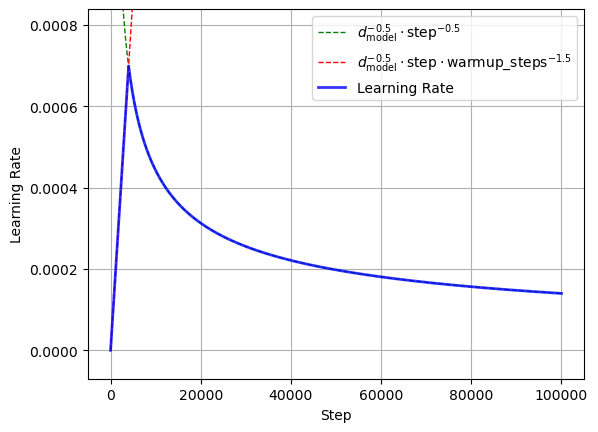

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

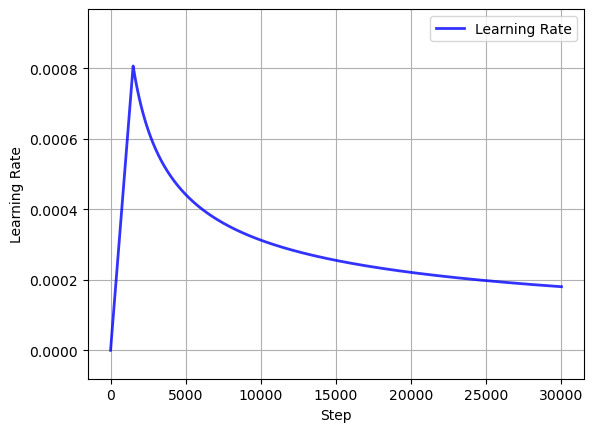

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

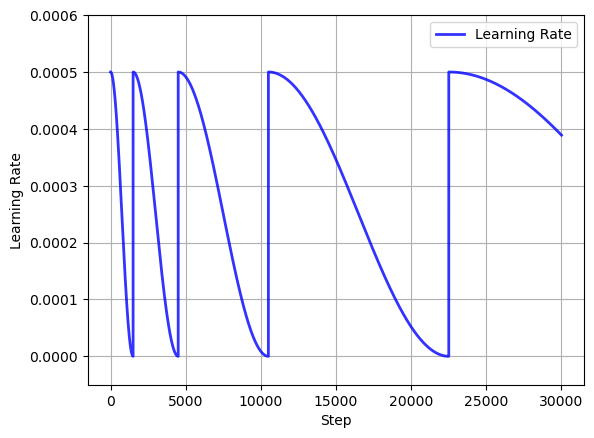

In [38]:
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

criterion = nn.CrossEntropyLoss(ignore_index = pad_idx) # pad token 이 출력 나와야하는 시점의 loss는 무시 (즉, label이 <pad> 일 때는 무시) # 저장된 모델
# criterion = nn.CrossEntropyLoss(ignore_index = pad_idx, label_smoothing = 0.1) # 막상 해보니 성능 안나옴 <- 데이터가 많아야 할 듯

scheduler_name = 'Noam'
# scheduler_name = 'Cos'
#### Noam ####
# warmup_steps = 4000 # 이건 논문에서 제시한 값 (총 10만 step의 4%)
warmup_steps = 1500 # 데이터 수 * EPOCH / BS = 총 step 수 인것 고려 # 저장된 모델
LR_scale = 0.5 # Noam scheduler에 peak LR 값 조절을 위해 곱해질 녀석 # 저장된 모델
#### Cos ####
LR_init = 5e-4
T0 = 1500 # 첫 주기
T_mult = 2 # 배 만큼 주기가 길어짐 (1보다 큰 정수여야 함)
#############


optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=0) # 테스트용 optimizer
scheduler = NoamScheduler(optimizer, d_model=512, warmup_steps=4000) # 논문 값
plot_scheduler(scheduler_name = 'Noam', optimizer = optimizer, scheduler = scheduler, total_steps = 100000)

optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=0)
scheduler = NoamScheduler(optimizer, d_model=d_model, warmup_steps=warmup_steps, LR_scale=LR_scale)
plot_scheduler(scheduler_name = 'Noam', optimizer = optimizer, scheduler = scheduler, total_steps = int(len(train_dataset)*EPOCH/BATCH_SIZE)) # 내 상황

optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=LR_init)
scheduler = CosineAnnealingWarmRestarts(optimizer, T0, T_mult)
plot_scheduler(scheduler_name = 'Cos', optimizer = optimizer, scheduler = scheduler, total_steps = int(len(train_dataset)*EPOCH/BATCH_SIZE))

In [44]:
# 모델 학습 여부 설정
train_model = True  # 모델을 학습하려면 True, 이미 학습된 모델을 사용하려면 False

# 모델 훈련
if train_model == True:
  scheduler_name = "Cos"
  LAMBDA = 0

  params = [p for p in model.parameters() if p.requires_grad] # 사전 학습된 layer를 사용할 경우
  if scheduler_name == 'Noam':
      optimizer = optim.Adam(params, lr=0,
                              betas=(0.9, 0.98), eps=1e-9,
                              weight_decay=LAMBDA) # 논문에서 제시한 beta와 eps 사용, l2-Regularization은 한번 써봄 & 맨 처음 step 의 LR=0으로 출발 (warm-up)
      scheduler = NoamScheduler(optimizer, d_model=d_model, warmup_steps=warmup_steps, LR_scale=LR_scale)

  elif scheduler_name == 'Cos':
      optimizer = optim.Adam(params, lr=LR_init,  # cos restart sheduling
                              betas=(0.9, 0.98), eps=1e-9,
                              weight_decay=LAMBDA)
      scheduler = CosineAnnealingWarmRestarts(optimizer, T0, T_mult)

  Train(model, train_DL, val_DL, criterion, optimizer, scheduler)
else:
  # history
  !gdown https://drive.google.com/uc?id=14XJXRUEzNU67Pk9NQ69IFtwC85VfqmCs -O "transformer_history.pt"

  # model
  !gdown https://drive.google.com/uc?id=1Dwwp1Q444qL-5B5Yf_eADwi4WYPnZxui -O "transformer_model.pt"

RuntimeError: Placeholder storage has not been allocated on MPS device!

# 저장된 모델 불러오기

In [45]:
loaded = torch.load(save_model_path, map_location=DEVICE)
load_model = loaded["model"]
ep = loaded["ep"]
optimizer = loaded["optimizer"]

loaded = torch.load(save_history_path, map_location=DEVICE)
loss_history = loaded["loss_history"]

print(ep)
print(optimizer)

/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_11434/2401509439.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(save_model_path, map_loca

FileNotFoundError: [Errno 2] No such file or directory: 'transformer_model.pt'

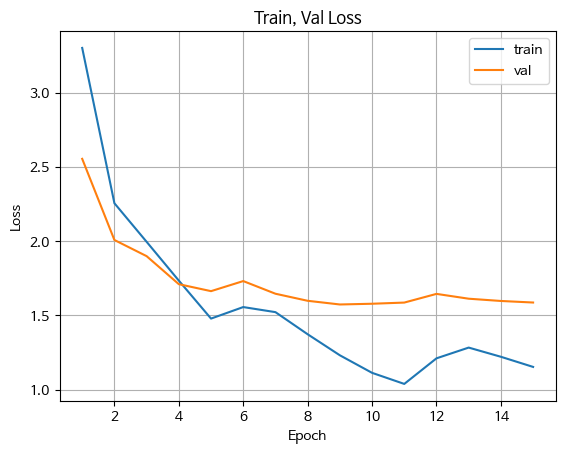

In [ ]:
plt.figure()
plt.plot(range(1,EPOCH+1),loss_history["train"], label="train")
plt.plot(range(1,EPOCH+1),loss_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train, Val Loss")
plt.grid()
plt.legend()

In [ ]:
Test(load_model, test_DL, criterion)
count_params(load_model)

Test loss: 2.928 | Test PPL: 18.695


37364713

# 모델 사용해보기

In [ ]:
# 번역 함수
def translation(model, src_text, atten_map_save = False):
    model.eval()
    with torch.no_grad():
        src = tokenizer.encode(src_text, return_tensors='pt').to(DEVICE) # 1x단
        enc_mask = model.make_enc_mask(src)
        enc_out, atten_encs = model.encoder(src, enc_mask, atten_map_save)

        pred = tokenizer.encode('</s>', return_tensors='pt', add_special_tokens=False).to(DEVICE) # 1x1
        for _ in range(max_len-1): # <sos> 가 한 토큰이기 때문에 최대 99 번까지만 loop을 돌아야 함
            dec_mask = model.make_dec_mask(pred)
            enc_dec_mask = model.make_enc_dec_mask(src, pred)
            out, atten_decs, atten_enc_decs = model.decoder(pred, enc_out, dec_mask, enc_dec_mask, atten_map_save)

            pred_word = out.argmax(dim=2)[:,-1].unsqueeze(0) # shape = (1,1)
            pred = torch.cat([pred, pred_word], dim=1) # 1x단 (단은 하나씩 늘면서)

            if tokenizer.decode(pred_word.item()) == '</s>':
                break

        translated_text = tokenizer.decode(pred[0])

    return translated_text, atten_encs, atten_decs, atten_enc_decs

# 어텐션 시각화
def show_attention(atten, Query, Key, n):
    atten = atten.cpu()

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=[atten.shape[3]*1.5,atten.shape[2]])
    for i in range(3):
        ax[i].set_yticks(range(atten.shape[2]))
        ax[i].set_yticklabels(Query, rotation=45)
        ax[i].set_xticks(range(atten.shape[3]))
        ax[i].set_xticklabels(Key, rotation=60)
        ax[i].imshow(atten[n][i], cmap='bone') # n 번째 layer, 앞 세 개의 헤드만 plot
        # ax[i].xaxis.tick_top()  # x축 레이블을 위쪽으로 이동

In [ ]:
# src_text = test_dataset[100][0]
# trg_text = test_dataset[100][1]

src_text = "오늘 날씨는 비가 오다가 맑아졌습니다."
trg_text = "The weather today is rainy and then clear."
print(f"입력: {src_text}")
print(f"정답: {trg_text}")

translated_text, atten_encs, atten_decs, atten_enc_decs = translation(load_model, src_text, atten_map_save = True)
print(f"AI의 번역: {translated_text}")

입력: 오늘 날씨는 비가 오다가 맑아졌습니다.
정답: The weather today is rainy and then clear.
AI의 번역: </s> There was during the kids of the kids of the earlimited times being during the earlimited time of the kids.</s>


In [ ]:
# teacher forcing 으로 넣어본다면?

src = tokenizer.encode(src_text, return_tensors='pt').to(DEVICE)
trg_text = '</s> ' + trg_text
trg = tokenizer.encode(trg_text, return_tensors='pt').to(DEVICE)

load_model.eval()
with torch.no_grad():
    y_hat = load_model(src, trg[:,:-1])[0]
    loss = criterion(y_hat.permute(0,2,1), trg[:,1:])
    out_token = y_hat.argmax(-1).squeeze()
    out_text = tokenizer.decode(out_token)

print('loss =', loss)
print('정답 =', ' '.join([tokenizer.decode(i) for i in trg[0,1:]]))
print('예측 =', ' '.join([tokenizer.decode(i) for i in out_token]))

loss = tensor(3.8875, device='cuda:0')
정답 = The we ather to day is r ain y and the n  cle ar . </s>
예측 = The re ight  p be  ain ing be   of le an ed The


# Self-Attention 확인

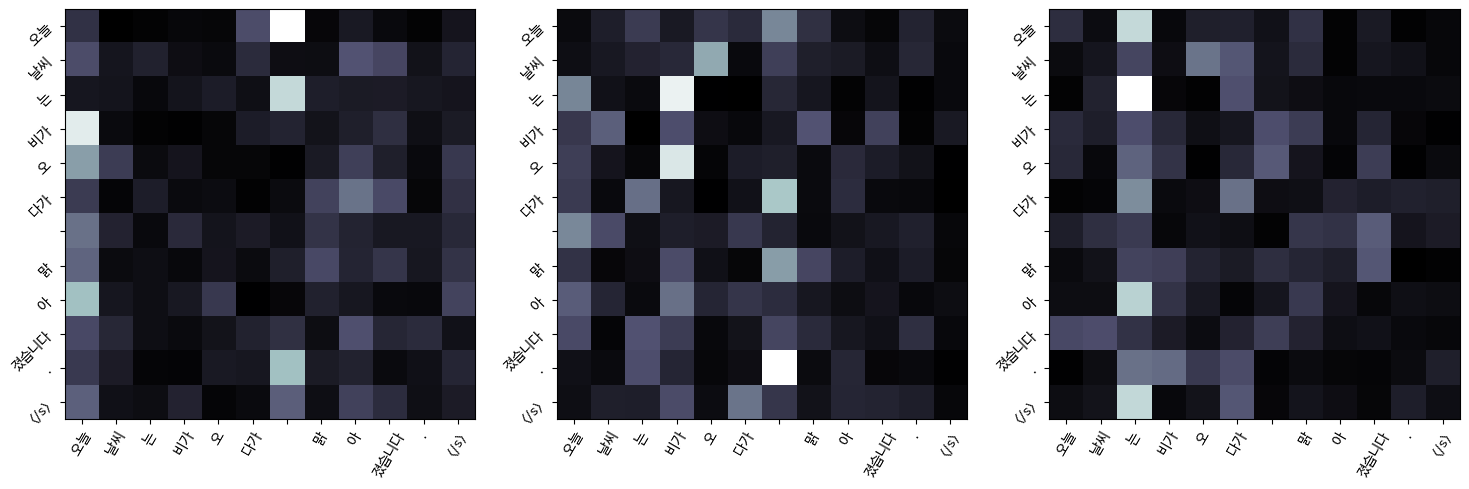

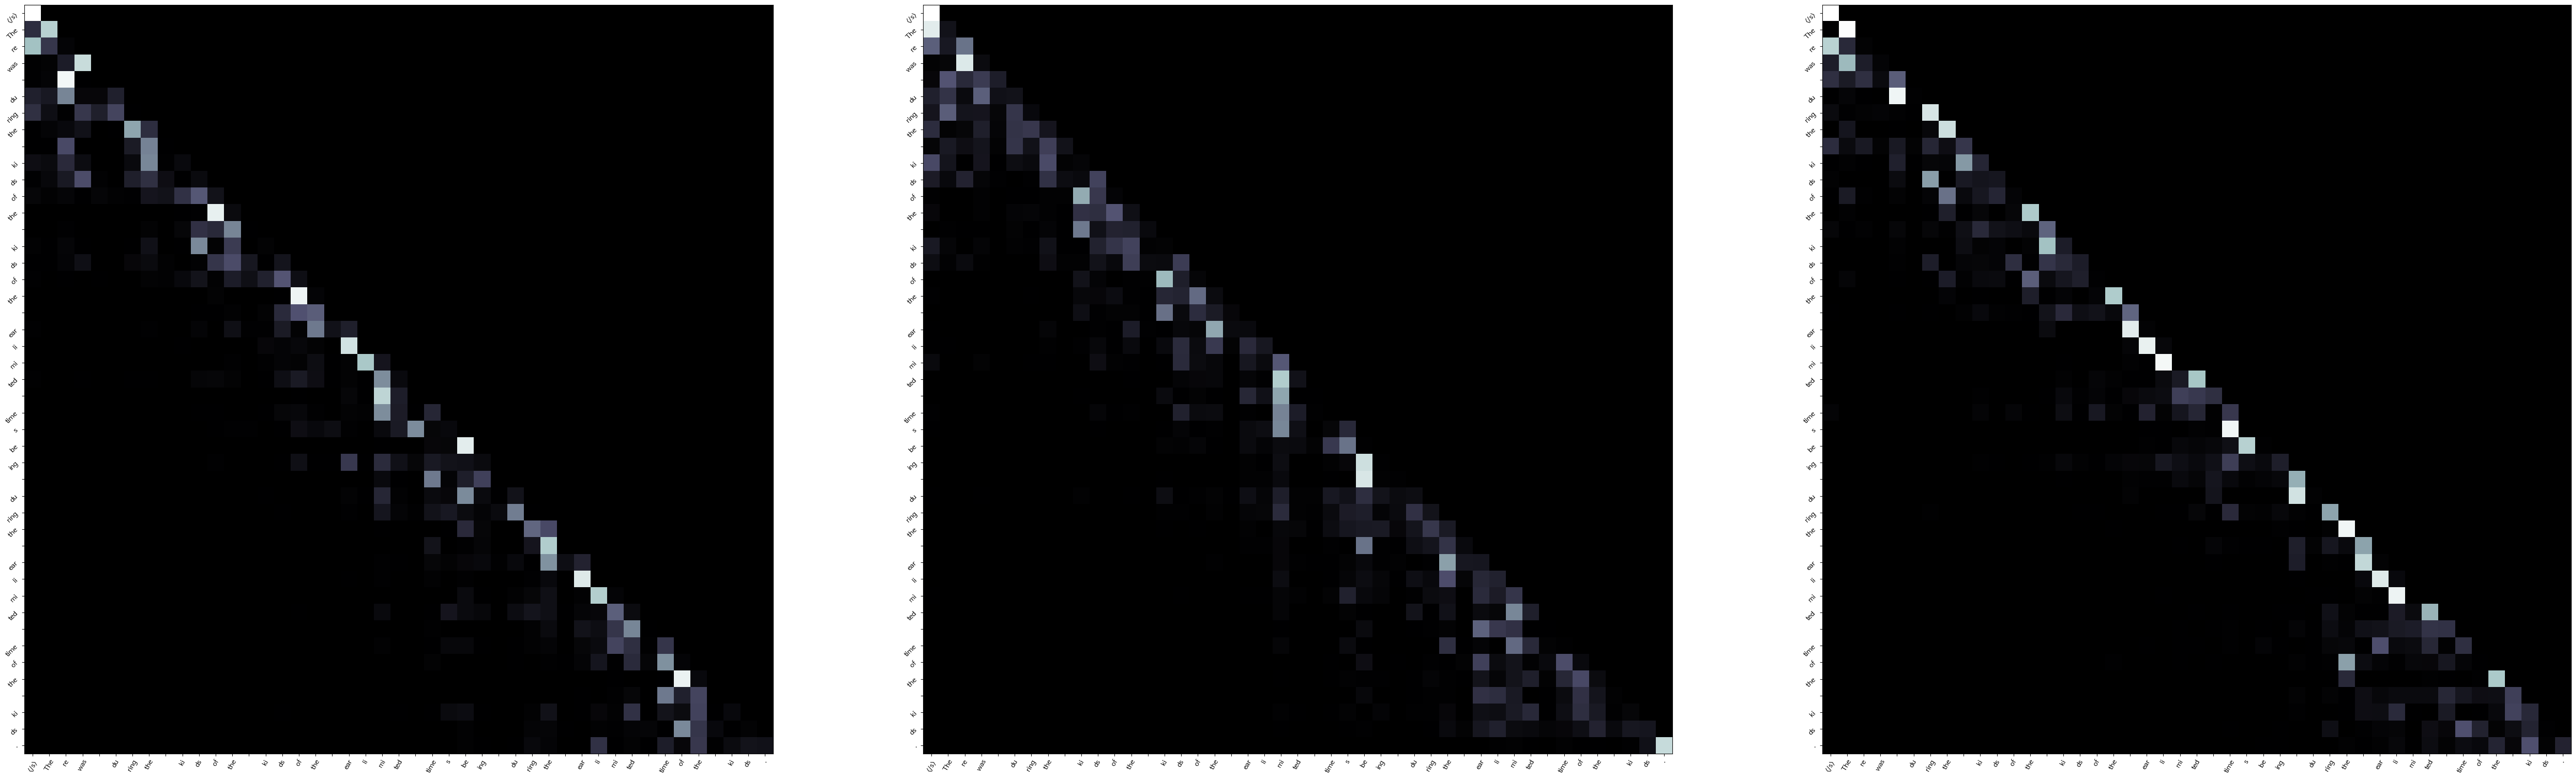

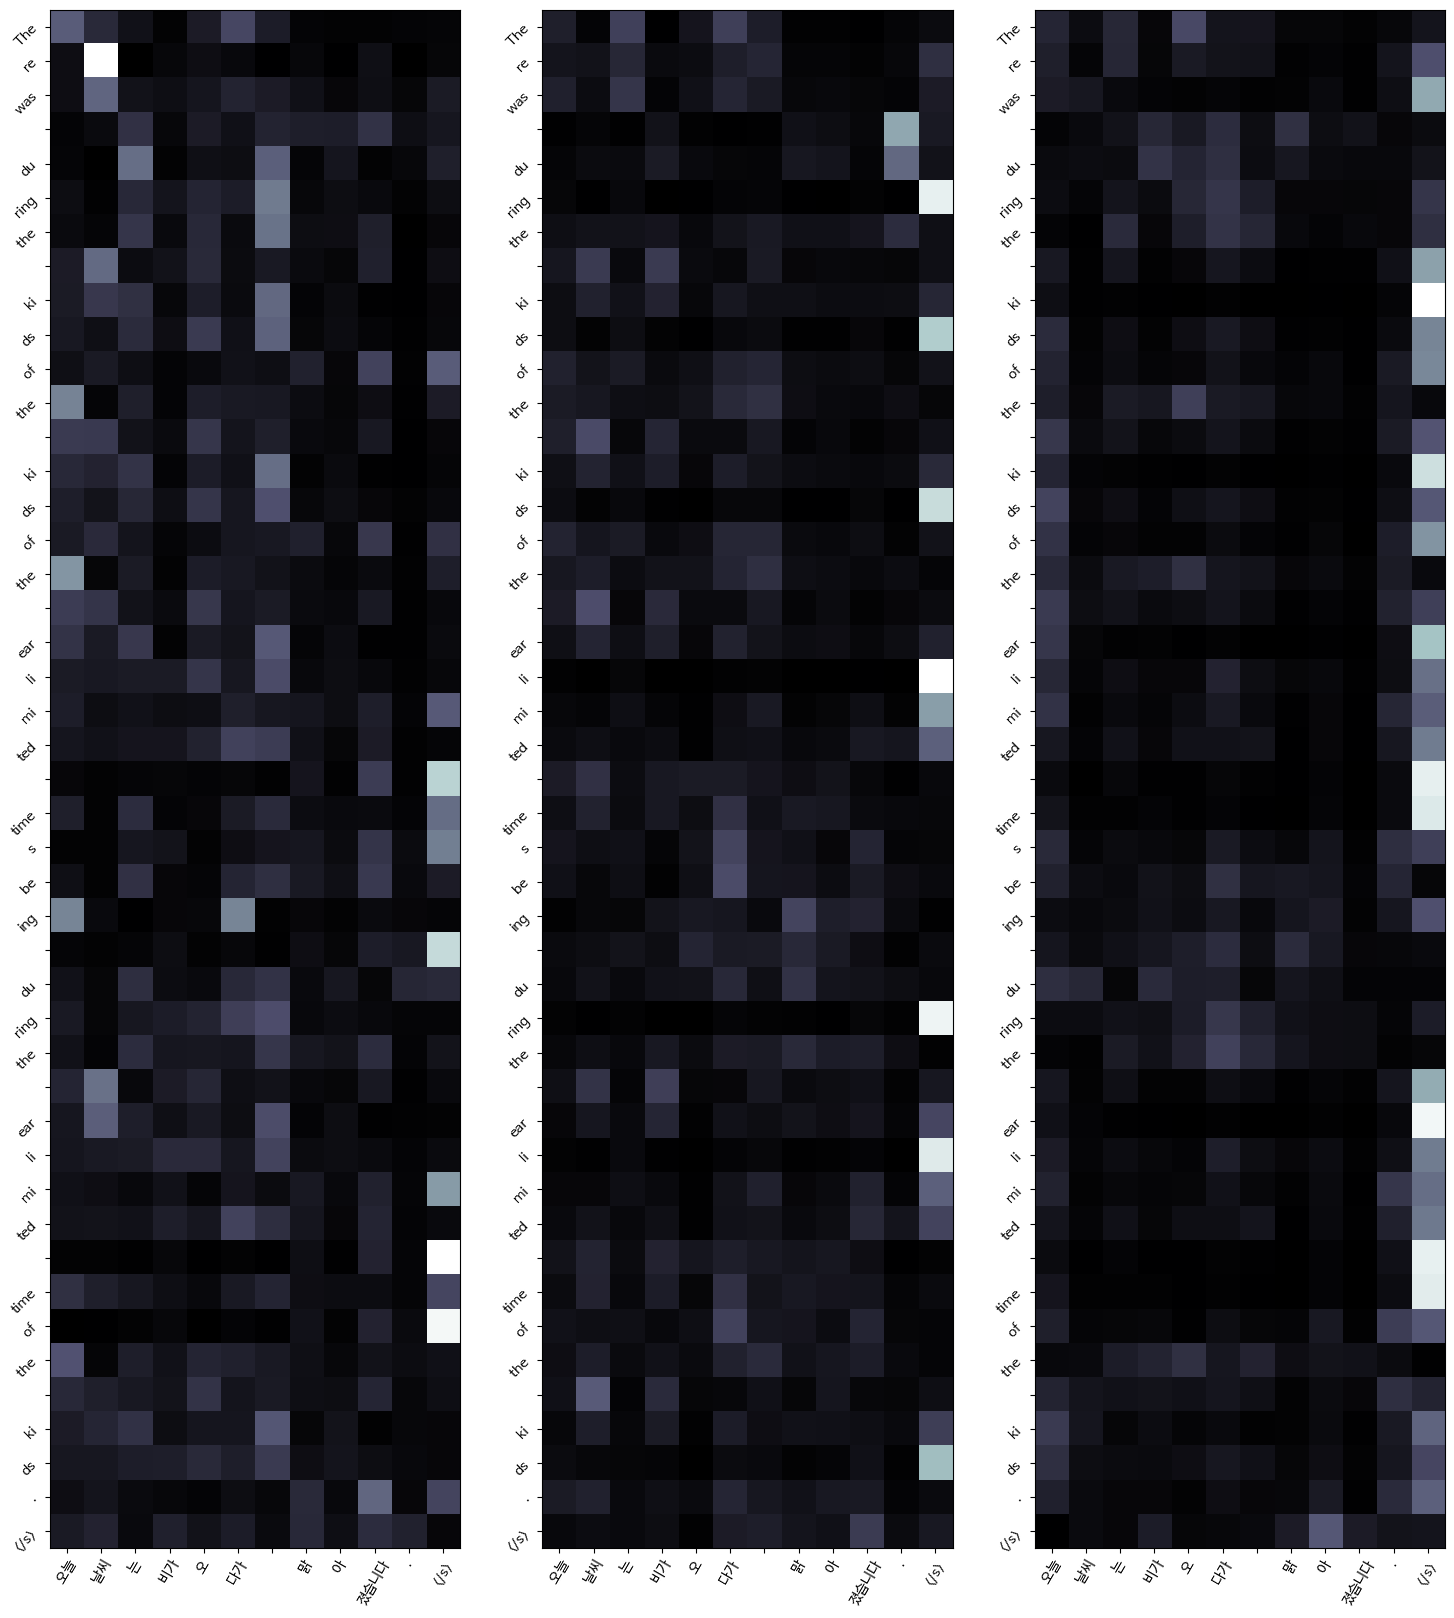

In [ ]:
enc_input = tokenizer.tokenize(src_text+' </s>') # <eos> 붙여서 학습 시켰기 때문에 여기도 붙여줘야
dec_tokens = tokenizer.tokenize(translated_text)
dec_input = dec_tokens[:-1] # 디코더 입력으로 들어가는 문장(sos 는 있고 eos는 없고)
dec_output = dec_tokens[1:] # 디코더 출력으로 나간 문장

# print(dec_input)
# print(atten_enc_dec.shape)
# print(len(dec_input))
# print(len(enc_input))

show_attention(atten_encs, enc_input, enc_input, n = 1) # 백화점 1층은 사원 헤드 (두루두루) 2층은 부장 헤드 3층은 임원 헤드
show_attention(atten_decs, dec_input, dec_input, n = 1)
show_attention(atten_enc_decs, dec_output, enc_input, n = 1) # 이 map을 해석할 때는 "이 단어가 나오게끔 뭘 주목했느냐" 로 해석해줘야 함 (ytick에 들어가는 단어가 아닌 예측한 단어를 썼기 때문)

# BLEU Score 확인하기

In [ ]:
from torchtext.data.metrics import bleu_score

def calc_bleu_score(model, DS):
    trgs = []
    preds = []

    for i, (src_text, trg_text) in enumerate(DS):

        translated_text, _, _, _ = translation(load_model, src_text)

        trg = tokenizer.tokenize(trg_text)
        translated_tok = tokenizer.tokenize(translated_text)[1:-1] # <sos> & <eos> 제외

        trgs += [[trg]]
        preds += [translated_tok]

        if (i + 1) % 100 == 0:
            print(f"[{i + 1}/{len(DS)}]")
            print(f"입력: {src_text}")
            print(f"정답: {trg_text}")
            print(f"AI의 번역: {translated_text[5:-4]}") # 문자열에서 </s> 안보이게 하려고..

    bleu = bleu_score(preds, trgs)
    print()
    print(f'Total BLEU Score = {bleu*100:.2f}')

/usr/local/lib/python3.10/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [ ]:
calc_bleu_score(load_model, test_dataset)

[100/20000]
입력: 우리 회사에 대해서 잘 아시는 분이고, 관련 경험도 많으신 분입니다.
정답: He knows our company well and has a lot of relative experience.
AI의 번역: Our company is well, experiences about our person who is experience to work.
[200/20000]
입력: 죄송합니다만, 성함을 알려주시겠습니까?
정답: I am sorry. Could you tell me your name?
AI의 번역: I'm sorry, could you tell me your name?
[300/20000]
입력: 열심히 쓰기는 했는데 실수한 부분이 있나 보네요, 어느 부분인가요?
정답: I worked hard on it, but it seems like there is a place I made a mistake, which part is it?
AI의 번역: I used to use my hard, but which part is the part?
[400/20000]
입력: 그럴 리가 없는데, 저희가 시골에서 최상의 제품들만 구매해서 판매하고 있는데요.
정답: That can't happen, we only buy the best quality from the countryside and sell it.
AI의 번역: No way, we only sell the best country at the countryside.
[500/20000]
입력: 맛은 정말 좋은데 애들 먹이기에는 좀 짜네요.
정답: It tastes really good, but it's a bit salty to give to the kids.
AI의 번역: It's really good, but feed the kids' feeding blood is salty.
[600/20000]
입력: 여기 부근에 지하철역이 있다고 아까 만난 현지인이 말했는데.
정답: The l

성능이 막 좋아보이진 않는다.. 그래도 "나는 차였다"를 "I was a car"로 번역 하진 않잖아.. 한잔해